# Import Evaluation Metrics

In [31]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import joblib
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix


In [32]:
import joblib

best_rf = joblib.load("../Model/best_rf_model.pkl")

X_test = pd.read_csv("../data/X_test.csv")
y_test = pd.read_csv("../data/y_test.csv")


In [33]:
y_test = y_test.values.ravel()


# Import Evaluation Metrics

In [51]:
import joblib

best_rf = joblib.load("../Model/best_rf_model.pkl")

X_test = pd.read_csv("../data/X_test.csv")
y_test = pd.read_csv("../data/y_test.csv")


In [52]:
y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:,1]

In [53]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report


In [54]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


Accuracy: 0.8852459016393442
Precision: 0.8181818181818182
Recall: 0.9642857142857143
F1-Score: 0.8852459016393442
ROC-AUC: 0.9523809523809523


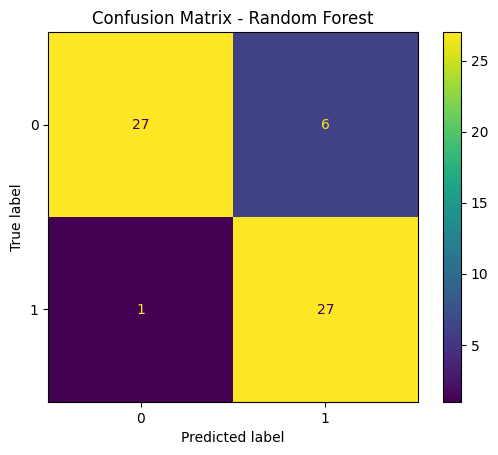

In [55]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix - Random Forest")
plt.show()


In [56]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.96      0.82      0.89        33
           1       0.82      0.96      0.89        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.90      0.89      0.89        61



# ROC curve For Random forest

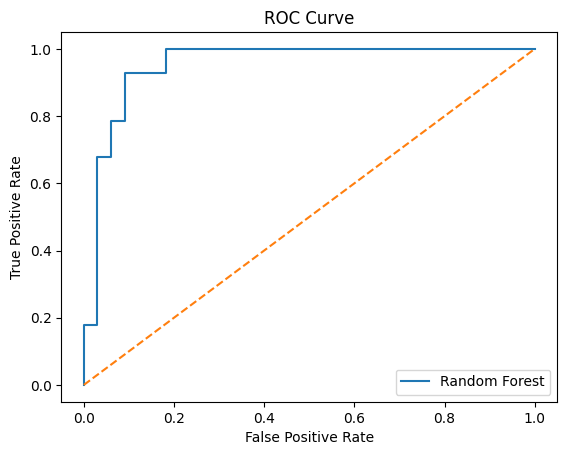

In [57]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


# Load Both Tuned Models

In [58]:
import joblib
import pandas as pd

best_rf = joblib.load("../Model/best_rf_model.pkl")
best_xgb = joblib.load("../Model/best_xgb_model.pkl")

X_test = pd.read_csv("../data/X_test.csv")
y_test = pd.read_csv("../data/y_test.csv")

y_test = y_test.values.ravel()


# Get Prediction Probabilities

In [59]:
rf_prob = best_rf.predict_proba(X_test)[:,1]
xgb_prob = best_xgb.predict_proba(X_test)[:,1]


# Generate ROC Curve for BOTH Models

In [60]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt


In [61]:
# RF ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
auc_rf = roc_auc_score(y_test, rf_prob)

# XGB ROC
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_prob)
auc_xgb = roc_auc_score(y_test, xgb_prob)

# Final Combined ROC Plot

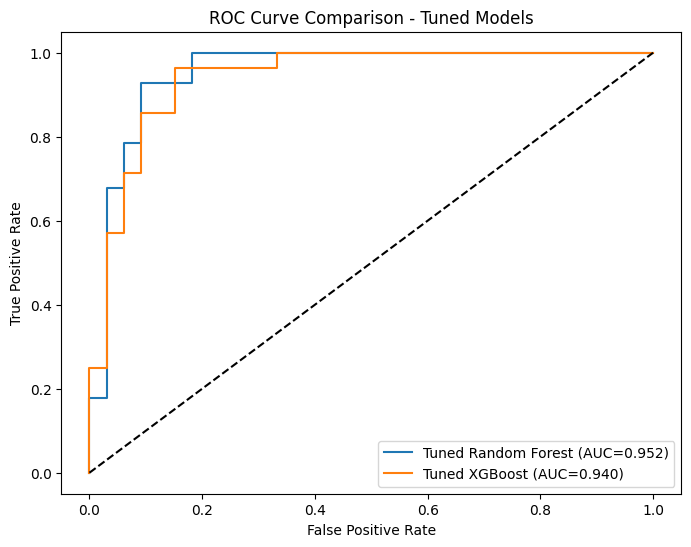

In [62]:
plt.figure(figsize=(8,6))

plt.plot(fpr_rf, tpr_rf, label=f"Tuned Random Forest (AUC={auc_rf:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"Tuned XGBoost (AUC={auc_xgb:.3f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison - Tuned Models")
plt.legend()

plt.show()